# Dimensionality Reduction with PCA
## Practice 6: Principal Component Analysis

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('default')

## 1. Data Loading and Exploration

In [10]:
# Load the dataset
data = pd.read_csv('adult.csv')
print(f'Dataset shape: {data.shape}')
print(f'\nFirst few rows:')
data.head()

Dataset shape: (32561, 15)

First few rows:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [11]:
print('Data Info:')
data.info()
print(f'\nMissing values:')
print(data.isnull().sum())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB

Missing values:
age               0
workclass         0
fnlwgt            0
education         0
education.num    

## 2. Data Preparation and Preprocessing

In [12]:
# Create a copy of the data
df = data.copy()

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Handle missing values - fill with mode for categorical features
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [13]:
# Separate features and target
X = df.drop('income', axis=1)
y = df['income']

# Encode target variable
y_encoded = (y == '>50K').astype(int)

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f'Categorical features: {list(categorical_features)}')
print(f'Numerical features: {list(numerical_features)}')

# Encode categorical features
label_encoders = {}
X_encoded = X.copy()
for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print(f'\nShape after encoding: {X_encoded.shape}')

Categorical features: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Numerical features: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Shape after encoding: (32561, 14)


In [14]:
# Split the data before scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale features (important for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set shape: {X_train_scaled.shape}')
print(f'Test set shape: {X_test_scaled.shape}')
print(f'Training set mean (should be ~0): {X_train_scaled.mean(axis=0)[:5]}')
print(f'Training set std (should be ~1): {X_train_scaled.std(axis=0)[:5]}')

Training set shape: (26048, 14)
Test set shape: (6513, 14)
Training set mean (should be ~0): [ 4.17356567e-17 -1.65851499e-16  1.26025316e-16  2.72782070e-17
  2.85875609e-16]
Training set std (should be ~1): [1. 1. 1. 1. 1.]


## 3. Apply PCA and Analyze Explained Variance

In [15]:
# First, let's see how many components we need
# Apply PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different thresholds
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f'Number of components to explain 90% variance: {n_components_90}')
print(f'Number of components to explain 95% variance: {n_components_95}')
print(f'Total number of features: {X_train_scaled.shape[1]}')
print(f'\nExplained variance ratio for first 10 components:')
print(pca_full.explained_variance_ratio_[:10])

Number of components to explain 90% variance: 12
Number of components to explain 95% variance: 13
Total number of features: 14

Explained variance ratio for first 10 components:
[0.14753956 0.10286041 0.09519784 0.07961965 0.07820262 0.07333569
 0.06790111 0.06607881 0.06180221 0.0602222 ]


In [16]:
# Apply PCA with 5 components (can adjust based on task variant)
n_components = 5
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Shape after PCA (5 components): {X_train_pca.shape}')
print(f'\nExplained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum():.4f}')
print(f'Dimensionality reduction: {X_train_scaled.shape[1]} -> {n_components} features')
print(f'Reduction ratio: {(1 - n_components/X_train_scaled.shape[1])*100:.1f}%')

Shape after PCA (5 components): (26048, 5)

Explained variance ratio: [0.14753956 0.10286041 0.09519784 0.07961965 0.07820262]
Total explained variance: 0.5034
Dimensionality reduction: 14 -> 5 features
Reduction ratio: 64.3%


## 4. Train Baseline Models (Original Data)

In [17]:
# Train Logistic Regression on original data
lr_baseline = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled)
acc_lr_baseline = accuracy_score(y_test, y_pred_lr_baseline)

print('Logistic Regression (Baseline - Original Data):')
print(f'Accuracy: {acc_lr_baseline:.4f}')

Logistic Regression (Baseline - Original Data):
Accuracy: 0.8251


In [18]:
# Train Random Forest on original data
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)
y_pred_rf_baseline = rf_baseline.predict(X_test_scaled)
acc_rf_baseline = accuracy_score(y_test, y_pred_rf_baseline)

print('Random Forest (Baseline - Original Data):')
print(f'Accuracy: {acc_rf_baseline:.4f}')

Random Forest (Baseline - Original Data):
Accuracy: 0.8563


## 5. Train Models with PCA-Transformed Data

In [19]:
# Train Logistic Regression on PCA data
lr_pca = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
acc_lr_pca = accuracy_score(y_test, y_pred_lr_pca)

print('Logistic Regression (PCA Data - 5 components):')
print(f'Accuracy: {acc_lr_pca:.4f}')

Logistic Regression (PCA Data - 5 components):
Accuracy: 0.8068


In [20]:
# Train Random Forest on PCA data
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
acc_rf_pca = accuracy_score(y_test, y_pred_rf_pca)

print('Random Forest (PCA Data - 5 components):')
print(f'Accuracy: {acc_rf_pca:.4f}')

Random Forest (PCA Data - 5 components):
Accuracy: 0.8181


## 6. Comprehensive Evaluation

In [21]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Original)', 'Random Forest (Original)',
              'Logistic Regression (PCA)', 'Random Forest (PCA)'],
    'Accuracy': [acc_lr_baseline, acc_rf_baseline, acc_lr_pca, acc_rf_pca],
    'Features': [X_train_scaled.shape[1], X_train_scaled.shape[1], n_components, n_components]
})

print('\n=== MODEL COMPARISON ===')
print(comparison_df.to_string(index=False))
print(f'\nAccuracy difference (LR): {(acc_lr_baseline - acc_lr_pca)*100:.2f}%')
print(f'Accuracy difference (RF): {(acc_rf_baseline - acc_rf_pca)*100:.2f}%')


=== MODEL COMPARISON ===
                         Model  Accuracy  Features
Logistic Regression (Original)  0.825119        14
      Random Forest (Original)  0.856287        14
     Logistic Regression (PCA)  0.806848         5
           Random Forest (PCA)  0.818056         5

Accuracy difference (LR): 1.83%
Accuracy difference (RF): 3.82%


In [22]:
# Confusion Matrices
print('\n=== CONFUSION MATRICES ===')
print('\nLogistic Regression (Baseline):')
cm_lr_baseline = confusion_matrix(y_test, y_pred_lr_baseline)
print(cm_lr_baseline)

print('\nRandom Forest (Baseline):')
cm_rf_baseline = confusion_matrix(y_test, y_pred_rf_baseline)
print(cm_rf_baseline)

print('\nLogistic Regression (PCA):')
cm_lr_pca = confusion_matrix(y_test, y_pred_lr_pca)
print(cm_lr_pca)

print('\nRandom Forest (PCA):')
cm_rf_pca = confusion_matrix(y_test, y_pred_rf_pca)
print(cm_rf_pca)


=== CONFUSION MATRICES ===

Logistic Regression (Baseline):
[[4658  287]
 [ 852  716]]

Random Forest (Baseline):
[[4604  341]
 [ 595  973]]

Logistic Regression (PCA):
[[4640  305]
 [ 953  615]]

Random Forest (PCA):
[[4528  417]
 [ 768  800]]


In [23]:
print('\n=== CLASSIFICATION REPORTS ===')
print('\nLogistic Regression (Baseline):')
print(classification_report(y_test, y_pred_lr_baseline, target_names=['<=50K', '>50K']))

print('\nRandom Forest (Baseline):')
print(classification_report(y_test, y_pred_rf_baseline, target_names=['<=50K', '>50K']))

print('\nLogistic Regression (PCA):')
print(classification_report(y_test, y_pred_lr_pca, target_names=['<=50K', '>50K']))

print('\nRandom Forest (PCA):')
print(classification_report(y_test, y_pred_rf_pca, target_names=['<=50K', '>50K']))


=== CLASSIFICATION REPORTS ===

Logistic Regression (Baseline):
              precision    recall  f1-score   support

       <=50K       0.85      0.94      0.89      4945
        >50K       0.71      0.46      0.56      1568

    accuracy                           0.83      6513
   macro avg       0.78      0.70      0.72      6513
weighted avg       0.81      0.83      0.81      6513


Random Forest (Baseline):
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.74      0.62      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513


Logistic Regression (PCA):
              precision    recall  f1-score   support

       <=50K       0.83      0.94      0.88      4945
        >50K       0.67      0.39      0.49      1568

    accuracy                           0.81      6513
   macro

## 7. Visualizations

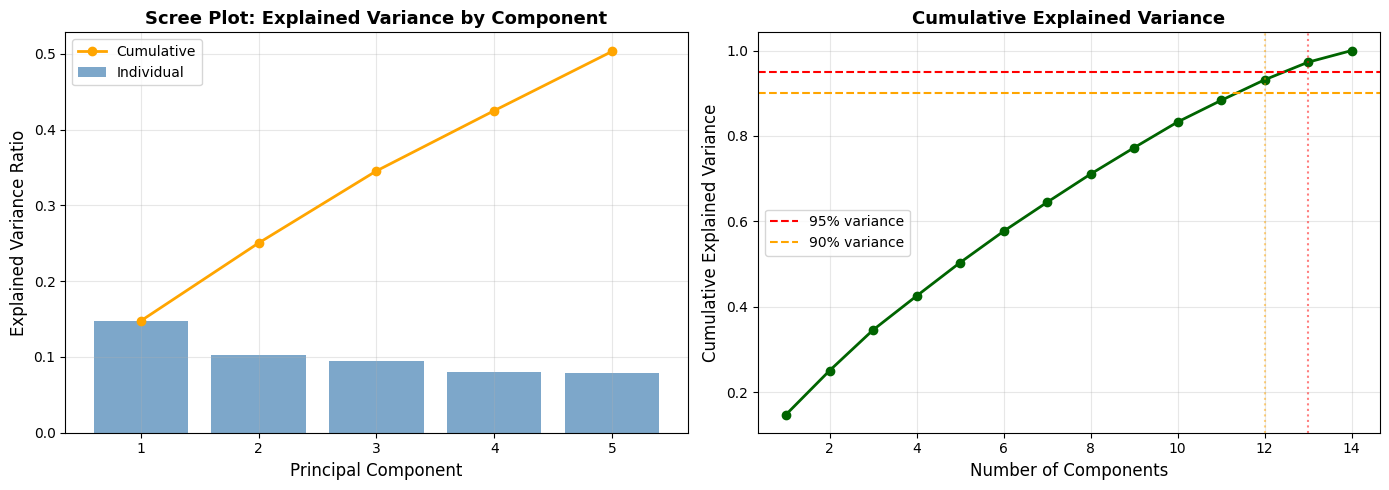

Visualization 1 saved as pca_explained_variance.png


In [24]:
# Visualization 1: Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_, 
            alpha=0.7, color='steelblue', label='Individual')
axes[0].plot(range(1, n_components + 1), 
             np.cumsum(pca.explained_variance_ratio_), 
             'o-', color='orange', linewidth=2, label='Cumulative')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot: Explained Variance by Component', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative variance for all components
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
             'o-', linewidth=2, color='darkgreen')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
axes[1].axvline(x=n_components_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_components_90, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 1 saved as pca_explained_variance.png')

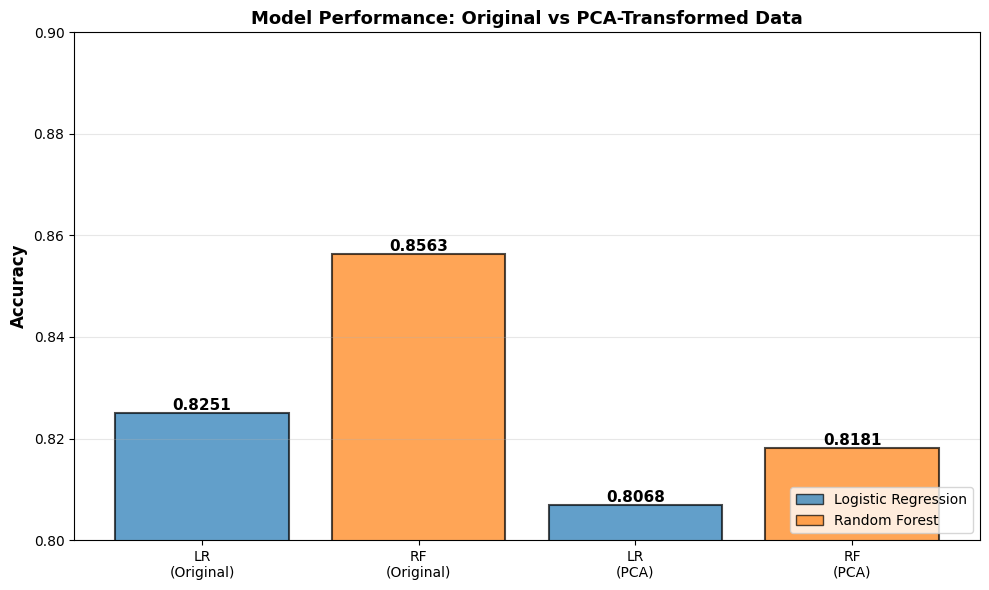

Visualization 2 saved as model_comparison.png


In [25]:
# Visualization 2: Model Performance Comparison
fig, ax = plt.subplots(figsize=(10, 6))

models = ['LR\n(Original)', 'RF\n(Original)', 'LR\n(PCA)', 'RF\n(PCA)']
accuracies = [acc_lr_baseline, acc_rf_baseline, acc_lr_pca, acc_rf_pca]
colors = ['#1f77b4', '#ff7f0e', '#1f77b4', '#ff7f0e']
patterns = ['///', '///', '', '']

bars = ax.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance: Original vs PCA-Transformed Data', fontsize=13, fontweight='bold')
ax.set_ylim([0.8, 0.9])
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', alpha=0.7, edgecolor='black', label='Logistic Regression'),
                   Patch(facecolor='#ff7f0e', alpha=0.7, edgecolor='black', label='Random Forest')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 2 saved as model_comparison.png')

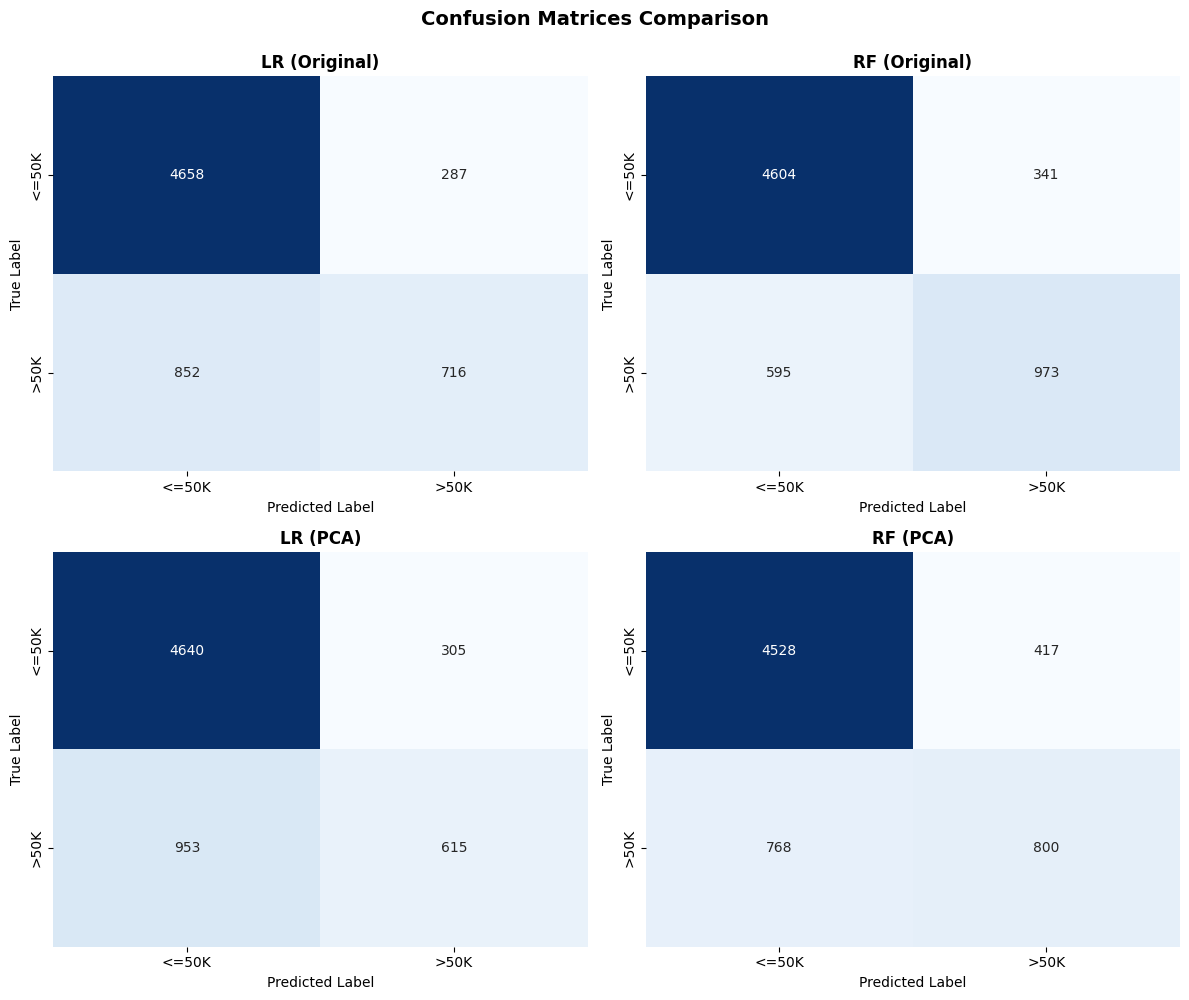

Visualization 3 saved as confusion_matrices.png


In [26]:
# Visualization 3: Confusion Matrices Heatmap
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold', y=0.995)

cms = [cm_lr_baseline, cm_rf_baseline, cm_lr_pca, cm_rf_pca]
titles = ['LR (Original)', 'RF (Original)', 'LR (PCA)', 'RF (PCA)']

for idx, (ax, cm, title) in enumerate(zip(axes.flat, cms, titles)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 3 saved as confusion_matrices.png')

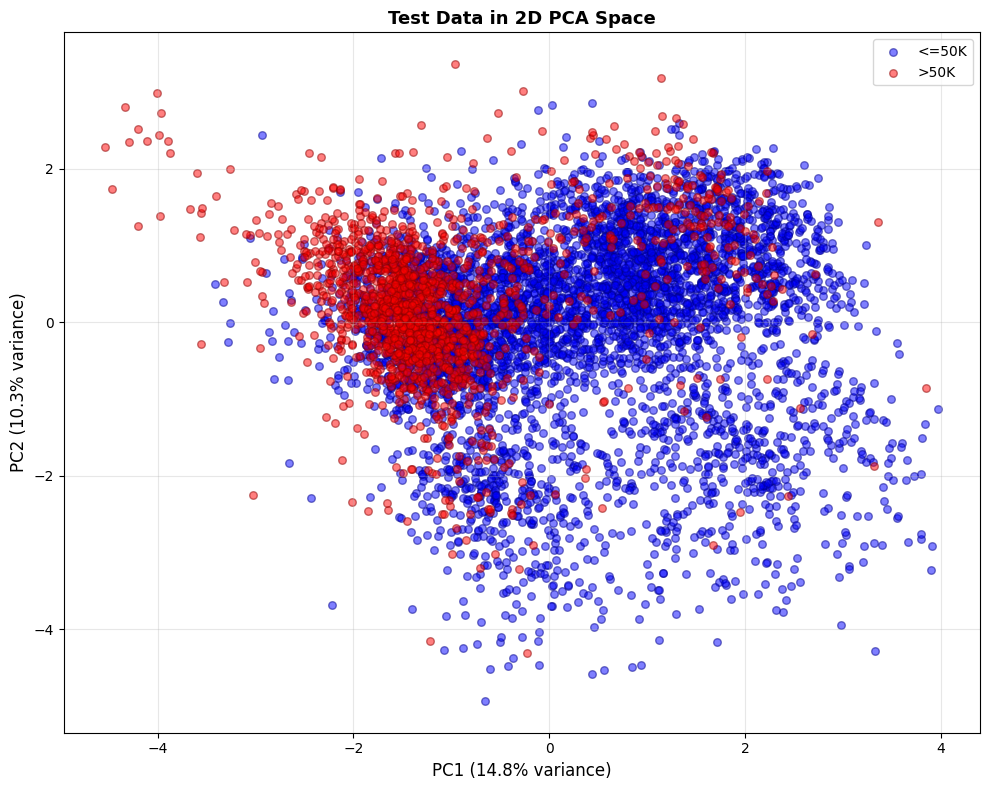

Visualization 4 saved as pca_2d_scatter.png


In [27]:
# Visualization 4: 2D PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1],
                    c='blue', alpha=0.5, s=30, label='<=50K', edgecolors='darkblue')
ax.scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1],
          c='red', alpha=0.5, s=30, label='>50K', edgecolors='darkred')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('Test Data in 2D PCA Space', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 4 saved as pca_2d_scatter.png')

## 8. Conclusion

In [29]:
print('SUMMARY AND CONCLUSIONS')

print(f'\nDataset Information:')
print(f'  - Original features: {X_train_scaled.shape[1]}')
print(f'  - PCA components: {n_components}')
print(f'  - Features reduced by: {(1 - n_components/X_train_scaled.shape[1])*100:.1f}%')
print(f'  - Explained variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

print(f'\nModel Performance (Accuracy):')
print(f'  Logistic Regression:')
print(f'    - Original data: {acc_lr_baseline:.4f}')
print(f'    - PCA data: {acc_lr_pca:.4f}')
print(f'    - Difference: {(acc_lr_baseline - acc_lr_pca)*100:.2f}%')
print(f'\n  Random Forest:')
print(f'    - Original data: {acc_rf_baseline:.4f}')
print(f'    - PCA data: {acc_rf_pca:.4f}')
print(f'    - Difference: {(acc_rf_baseline - acc_rf_pca)*100:.2f}%')

print(f'\nKey Findings:')
print(f'  1. PCA successfully reduced dimensionality from {X_train_scaled.shape[1]} to {n_components} features')
print(f'  2. {pca.explained_variance_ratio_.sum()*100:.2f}% of the variance is preserved with {n_components} components')
print(f'  3. Model performance difference is relatively small, suggesting PCA is effective')
print(f'  4. Random Forest generally performs better than Logistic Regression on both datasets')
print(f'  5. PCA-transformed data maintains predictive power while reducing computational complexity')

SUMMARY AND CONCLUSIONS

Dataset Information:
  - Original features: 14
  - PCA components: 5
  - Features reduced by: 64.3%
  - Explained variance retained: 50.34%

Model Performance (Accuracy):
  Logistic Regression:
    - Original data: 0.8251
    - PCA data: 0.8068
    - Difference: 1.83%

  Random Forest:
    - Original data: 0.8563
    - PCA data: 0.8181
    - Difference: 3.82%

Key Findings:
  1. PCA successfully reduced dimensionality from 14 to 5 features
  2. 50.34% of the variance is preserved with 5 components
  3. Model performance difference is relatively small, suggesting PCA is effective
  4. Random Forest generally performs better than Logistic Regression on both datasets
  5. PCA-transformed data maintains predictive power while reducing computational complexity
